<a href="https://colab.research.google.com/github/suleymagination/mechanistic-tomato-crop-model/blob/main/notebooks/model_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Repository Setup & Path Configuration for Google Colab

In [1]:
import os
import sys
from pathlib import Path

# Clone repository into Colab environment if running in cloud
repo_name = "mechanistic-tomato-crop-model"
repo_url = f"https://github.com/suleymagination/{repo_name}.git"

if not Path(repo_name).exists() and not Path("src").exists():
    !git clone {repo_url}
    os.chdir(repo_name)
elif Path(repo_name).exists():
    os.chdir(repo_name)

# Append project root to Python search path
sys.path.append(os.getcwd())

# Import custom modules directly from src/
from src.climate import ClimateDataLoader
from src.model import TomatoCropModel

print("Repository loaded successfully. Current directory:", os.getcwd())

Cloning into 'mechanistic-tomato-crop-model'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 131 (delta 66), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 1.08 MiB | 4.07 MiB/s, done.
Resolving deltas: 100% (66/66), done.
Repository loaded successfully. Current directory: /content/mechanistic-tomato-crop-model


## 2. Data Loading (Supports GitHub Raw URLs and Local Paths)

In [2]:
import pandas as pd

# Direct raw data URLs to ensure standard execution across Colab & local environments
climate_url = "https://raw.githubusercontent.com/suleymagination/mechanistic-tomato-crop-model/main/data/greenhouse_climate.csv"
harvest_url = "https://raw.githubusercontent.com/suleymagination/mechanistic-tomato-crop-model/main/data/harvest_summary.csv"

# Load climate time-series & compute daily physiological aggregates
loader = ClimateDataLoader(climate_url)
df_climate_raw = loader.load_data()
df_daily_climate = loader.get_daily_summaries(df_climate_raw)

# Load WUR empirical validation targets
df_harvest = pd.read_csv(harvest_url)
df_harvest["harvest_date"] = pd.to_datetime(df_harvest["harvest_date"]).dt.date

## 3. Execute Mechanistic Model Simulation

In [3]:
# Compartment 3.06 parameters: dynamic plant density from dataset, LUE = 8.4 g FW/mol PAR
model = TomatoCropModel(plant_density=25.3, lue_g_mol=8.4)
df_sim = model.run_simulation(df_daily_climate)
df_sim["date"] = pd.to_datetime(df_sim["date"]).dt.date

## 4. Validation Plot & Statistical Evaluation

     MODEL STATISTICAL EVALUATION       
• Mean Absolute Error (MAE)  : 28.57 g/pot
• Root Mean Sq. Error (RMSE) : 39.98 g/pot
• Mean Abs. Pct Error (MAPE) : 21.55%



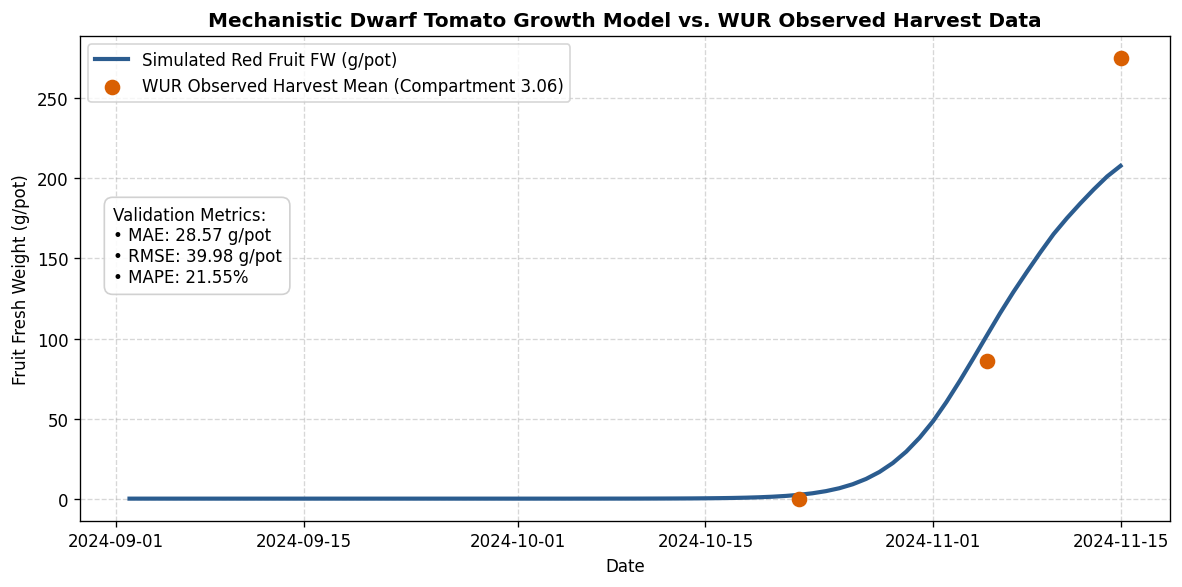

--- Validation Metrics Table ---


,harvest_date,Observed_g_pot,Simulated_g_pot
0,2024-10-22,0.0000,2.39
1,2024-11-05,85.6860,101.65
2,2024-11-15,275.1984,207.85


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Align simulated predictions with WUR harvest observation dates
df_obs_means = (
    df_harvest.groupby("harvest_date")["red_fw_g"]
    .mean()
    .reset_index()
    .dropna()
)
df_obs_means["harvest_date"] = pd.to_datetime(df_obs_means["harvest_date"]).dt.date

df_eval = pd.merge(
    df_obs_means,
    df_sim[["date", "fruit_fw_g_pot"]],
    left_on="harvest_date",
    right_on="date",
    how="inner"
)

# 2. Compute quantitative error metrics
y_true = df_eval["red_fw_g"].values
y_pred = df_eval["fruit_fw_g_pot"].values

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

# Mask zero values to prevent division by zero in MAPE
non_zero_mask = y_true > 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Print formatted text output for easy copying
print("========================================")
print("     MODEL STATISTICAL EVALUATION       ")
print("========================================")
print(f"• Mean Absolute Error (MAE)  : {mae:.2f} g/pot")
print(f"• Root Mean Sq. Error (RMSE) : {rmse:.2f} g/pot")
print(f"• Mean Abs. Pct Error (MAPE) : {mape:.2f}%")
print("========================================\n")

# 3. Generate chart with metrics overlay box
plt.figure(figsize=(10, 5), dpi=120)

plt.plot(
    df_sim["date"],
    df_sim["fruit_fw_g_pot"],
    label="Simulated Red Fruit FW (g/pot)",
    color="#2b5c8f",
    linewidth=2.5,
)

plt.scatter(
    df_obs_means["harvest_date"],
    df_obs_means["red_fw_g"],
    color="#d95f02",
    s=70,
    zorder=5,
    label="WUR Observed Harvest Mean (Compartment 3.06)",
)

metrics_text = f"Validation Metrics:\n• MAE: {mae:.2f} g/pot\n• RMSE: {rmse:.2f} g/pot\n• MAPE: {mape:.2f}%"
plt.gca().text(
    0.03, 0.65, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#cccccc", alpha=0.9)
)

plt.title("Mechanistic Dwarf Tomato Growth Model vs. WUR Observed Harvest Data", fontsize=12, fontweight="bold")
plt.xlabel("Date", fontsize=10)
plt.ylabel("Fruit Fresh Weight (g/pot)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 4. Display comparison table
print("--- Validation Metrics Table ---")
display(df_eval[["harvest_date", "red_fw_g", "fruit_fw_g_pot"]].rename(
    columns={"red_fw_g": "Observed_g_pot", "fruit_fw_g_pot": "Simulated_g_pot"}
))